Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96595.png


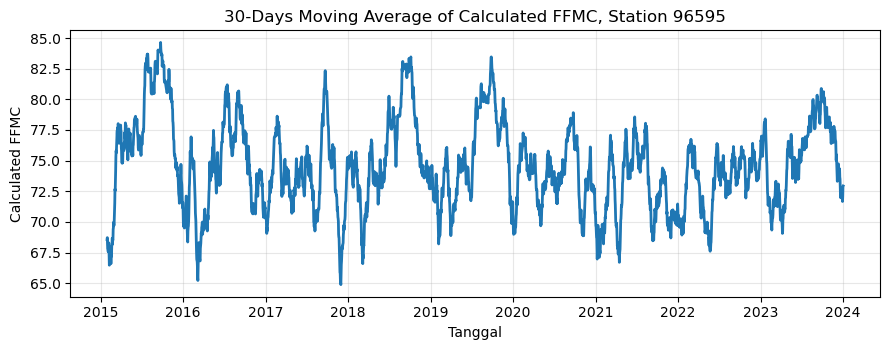

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96645.png


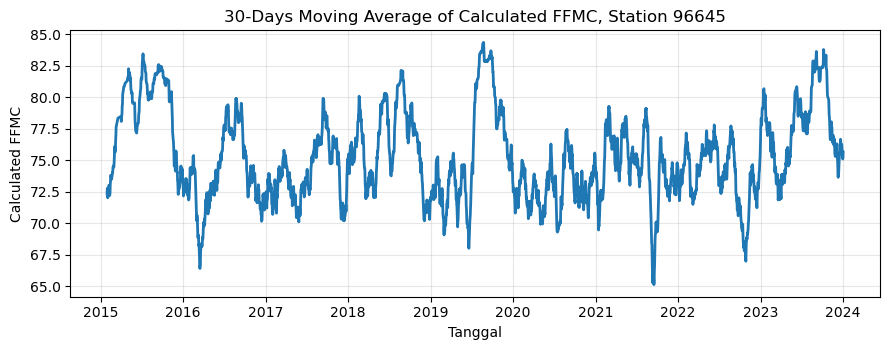

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96651.png


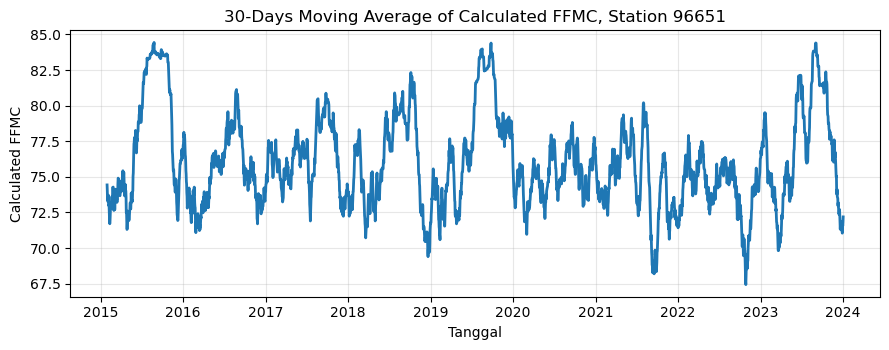

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96653.png


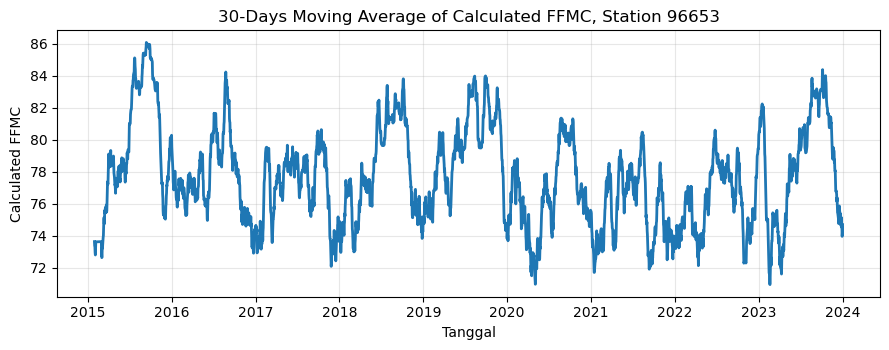

Saved: /home/rzby/ffmc_dc/reports/figures/ffmc_ma30_96655.png


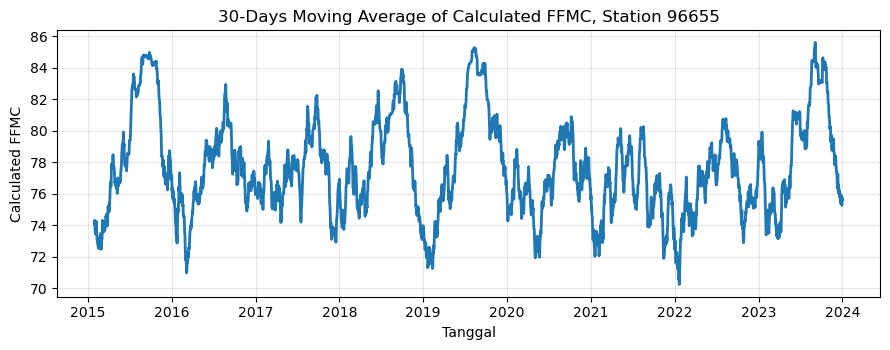

In [1]:
# === Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# === Path file (🔧 sesuaikan bila perlu)
CSV_PATH = Path("/home/rzby/ffmc_dc/data/processed/daily_features.csv")  # contoh lokasi
OUT_DIR   = Path("/home/rzby/ffmc_dc/reports/figures/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# === Baca Excel
df = pd.read_csv(CSV_PATH)

# --- Standarkan nama kolom agar mudah dideteksi
df.columns = [c.strip() for c in df.columns]

# === Deteksi kolom kunci (🔧 sesuaikan jika perlu)
# Tanggal: cari kolom yang mengandung 'date'
date_col = next((c for c in df.columns if "date" in c.lower()), None)
# Stasiun: cari 'station_id', 'wmo_id', 'wmo', atau 'station'
station_col = None
for key in ["station_id", "wmo_id", "wmo", "station"]:
    if station_col is None and any(key == c.lower() for c in df.columns):
        station_col = next(c for c in df.columns if c.lower() == key)
        break
# FFMC
ffmc_col = next((c for c in df.columns if c.lower() == "ffmc"), None)

assert date_col is not None,  "Kolom tanggal tidak ditemukan (cari yang mengandung 'date')."
assert station_col is not None,"Kolom stasiun tidak ditemukan (coba 'station_id'/'WMO'/'wmo_id')."
assert ffmc_col is not None,  "Kolom 'ffmc' tidak ditemukan."

# === Konversi tipe & sortir
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([station_col, date_col])

# === Hitung Moving Average 30 hari per stasiun
# Gunakan min_periods=30 agar MA-30 hanya terisi jika sudah ada 30 hari data
# (Jika ingin tidak ada NaN di awal deret, ganti min_periods=1)
df["ffmc_ma30"] = (
    df.groupby(station_col)[ffmc_col]
      .rolling(window=30, min_periods=30)
      .mean()
      .reset_index(level=0, drop=True)
)

# === Fungsi plot untuk satu stasiun
def plot_ma30_one_station(dfs, wmo_id, save_png=True):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(dfs[date_col], dfs["ffmc_ma30"], lw=2)

    # Sumbu waktu rapi
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Calculated FFMC")
    ax.set_title(f"30-Days Moving Average of Calculated FFMC, Station {wmo_id}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_png:
        out_path = OUT_DIR / f"ffmc_ma30_{wmo_id}.png"
        plt.savefig(out_path, dpi=300)
        print("Saved:", out_path)
    plt.show()

# === Loop semua stasiun dan plot
for sid, g in df.groupby(station_col):
    # Lewati jika semua nilai MA-30 NaN (mis. periode < 30 hari)
    if g["ffmc_ma30"].notna().any():
        plot_ma30_one_station(g, sid, save_png=True)
    else:
        print(f"Skip {sid}: belum cukup data untuk MA-30 (butuh ≥30 hari).")
